In this Notebook we run a test for all non-equivalent resolution-3 rules.

We run each rule for ...
- Three different networks: lattice, small-world, random of 900 nodes
- 900 initial configurations (for lattice), or 30 initial configurations on 30 networks (for non-lattice)
- 900 minimal perturbations
- 100 time steps (which arguably is too few)

For each of the 36 rules, we therefore get 900 configuration evolutions and 900 damage evolutions.
- That's a total of 2 * (# rules) * (# nodes) * (# samples) * (# networks) * (# time steps) = 2 * 36 * 900 * 900 * 3 * 100 = 17.5 billion Booleans. This is at the very least 2 GB (uncompressed)
- We want to save this raw data in a systematic fashion
- We are eventually only interested in the average over all nodes (average state and average defect).
- From these network averages, we take the final $\Delta t$ time steps of every sample.
- Then we take the median and the interquartile range (IQR) over these time steps and over the ensemble of 900 samples.
- We end up with a single value and its IQR for the state average $\bar{\rho}^T$ and the defect average $\bar{\delta}^T$, per rule, per network.
- We want to make three plots (one per network) of the final state average vs. the final defect average. Because we want to show that, just like the HW and the BS, these values are correlated.

# Load packages

In [5]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create networks

In [6]:
# PARAMETERS
#####################################################################################################################
L = 30                              # Grid size (L x L) WATCH OUT with values, becomes computationally expensive fast
num_nodes = L**2
rewiring_prob = 0.2                 # Rewiring probability for the small-world network
degree = 8                          # degree for lattice model (Moore neighbourhood)
num_edges = num_nodes * degree // 2 # number of undirected edges
num_graphs_per_type = 30
num_init_conf_per_graph = 30
init_dens = 0.5
T = 100
delta_t = 10
#####################################################################################################################

graph_names = ["Toroidal Lattice", f"Small World", "Random"]

# Create toroidal lattice
lattice_graph = create_2d_torus_lattice(L, degree=degree)
lattice_graphs = [lattice_graph]*num_graphs_per_type

# create small_world graphs. These are connected (see definition)
small_world_graphs = [watts_strogatz_rewire(lattice_graph, rewiring_prob) for _ in range(num_graphs_per_type)]

# create connected random graphs
random_graphs = []
for _ in range(num_graphs_per_type):
    while True:
        random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, m=num_edges)
        if random_graph.is_connected():
            random_graphs.append(random_graph)
            break

# find edges
lattice_edges = []
for lattice_graph in lattice_graphs:
    lattice_graph.to_directed()
    lattice_edge = tc.tensor(lattice_graph.get_edgelist()).T
    lattice_edges.append(lattice_edge)
    lattice_graph.to_undirected()

small_world_edges = []
for small_world_graph in small_world_graphs:
    small_world_graph.to_directed()
    small_world_edge = tc.tensor(small_world_graph.get_edgelist()).T
    small_world_edges.append(small_world_edge)
    small_world_graph.to_undirected()

random_edges = []
for random_graph in random_graphs:
    random_graph.to_directed()
    random_edge = tc.tensor(random_graph.get_edgelist()).T
    random_edges.append(random_edge)
    random_graph.to_undirected()

graphs_per_type = [lattice_graphs, small_world_graphs, random_graphs]
edges_per_type = [lattice_edges, small_world_edges, random_edges]

# Run over all non-equivalent rules and create configuration evolutions

In [ ]:
resolution = 3
beta_sigma_list = get_nonequiv_rules(resolution)

RUN_AGAIN = True

def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

if RUN_AGAIN:

    # open new lists. These will have dimensions [types][rules]
    state_medians_per_type = []
    state_q1_per_type = []
    state_q3_per_type = []
    defect_medians_per_type = []
    defect_q1_per_type = []
    defect_q3_per_type = []
    # loop over graph types
    for edges, graph_name in zip(edges_per_type, graph_names):
        print(f"Working on {graph_name} network. Now running through the non-equivalent rules ...")
        # open new lists
        state_medians_per_rule = []
        state_q1_per_rule = []
        state_q3_per_rule = []
        defect_medians_per_rule = []
        defect_q1_per_rule = []
        defect_q3_per_rule = []
        # loop over rules
        for beta, sigma in tqdm(beta_sigma_list, total=len(beta_sigma_list)):
            # initialise model
            B_set = binary_indices(beta)
            S_set = binary_indices(sigma)
            model = LLNA(resolution, B_set, S_set, iso=True)
            # get initial configurations
            init_configs_array = init_config_with_dens(num_nodes*num_init_conf_per_graph*num_graphs_per_type, init_dens)
            init_configs_array = init_configs_array.reshape(num_graphs_per_type, num_init_conf_per_graph, num_nodes)
            # get initial defects
            init_defects_array = np.eye(num_nodes, dtype=int)[np.random.choice(num_nodes, num_init_conf_per_graph*num_graphs_per_type, replace=False)]
            init_defects_array = init_defects_array.reshape(num_graphs_per_type, num_init_conf_per_graph, num_nodes)
            # find defected initial configurations
            init_configs_with_defect_array = (init_configs_array + init_defects_array) % 2
            # open new arrays that will collect all time series
            state_averages_stack = np.empty((0,T+1))
            defect_averages_stack = np.empty((0,T+1))
            # loop over graphs
            for edge, init_configs, init_configs_with_defect in zip(edges, init_configs_array, init_configs_with_defect_array):
                # evolve the configuration
                configs = model.forward(edge, tc.tensor(init_configs), T=T).numpy().astype(int)
                configs_with_defect = model.forward(edge, tc.tensor(init_configs_with_defect), T=T).numpy().astype(int)
                defects = (configs + configs_with_defect) % 2
                # get the average over all nodes
                state_averages = np.mean(configs, axis=2)
                defect_averages = np.mean(defects, axis=2)
                # add these to the stack
                state_averages_stack = np.vstack((state_averages_stack, state_averages))
                defect_averages_stack = np.vstack((defect_averages_stack, defect_averages))
            # get the median and IQR for the ensemble
            state_median, state_q1, state_q3 = median_and_percentiles_over_ensemble(state_averages_stack, delta_t=delta_t)
            defect_median, defect_q1, defect_q3 = median_and_percentiles_over_ensemble(defect_averages_stack, delta_t=delta_t)
            # append to lists
            state_medians_per_rule.append(state_median)
            state_q1_per_rule.append(state_q1)
            state_q3_per_rule.append(state_q3)
            defect_medians_per_rule.append(defect_median)
            defect_q1_per_rule.append(defect_q1)
            defect_q3_per_rule.append(defect_q3)
        # append to lists
        state_medians_per_type.append(state_medians_per_rule)
        state_q1_per_type.append(state_q1_per_rule)
        state_q3_per_type.append(state_q3_per_rule)
        defect_medians_per_type.append(defect_medians_per_rule)
        defect_q1_per_type.append(defect_q1_per_rule)
        defect_q3_per_type.append(defect_q3_per_rule)

    # turn lists into numpy arrays
    state_medians_per_type = np.array(state_medians_per_type)
    state_q1_per_type = np.array(state_q1_per_type)
    state_q3_per_type = np.array(state_q3_per_type)
    defect_medians_per_type = np.array(defect_medians_per_type)
    defect_q1_per_type = np.array(defect_q1_per_type)
    defect_q3_per_type = np.array(defect_q3_per_type)

Working on Toroidal Lattice network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [17:33<00:00, 29.26s/it]


Working on Small World network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [18:44<00:00, 31.22s/it]


Working on Random network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [18:26<00:00, 30.74s/it]


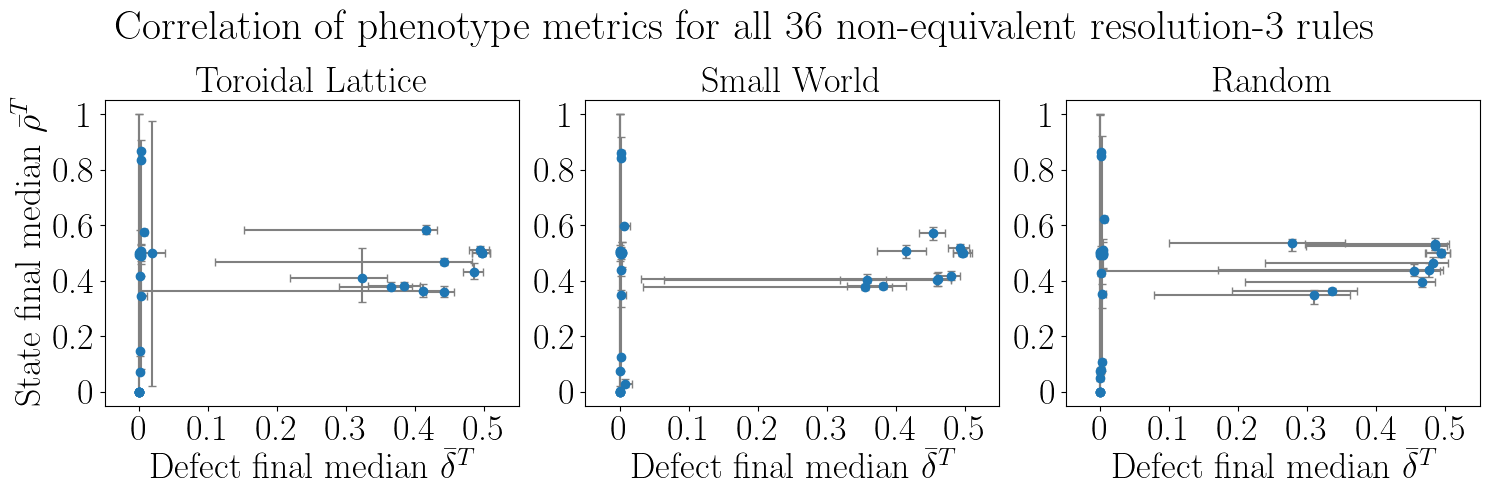

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(15,5))
fontsize=26

for idx, ax in enumerate(axs):
    graph_name = graph_names[idx]
    state_medians = state_medians_per_type[idx]
    state_err = [state_medians - state_q1_per_type[idx], state_q3_per_type[idx] - state_medians]
    defect_medians = defect_medians_per_type[idx]
    defect_err = [defect_medians - defect_q1_per_type[idx], defect_q3_per_type[idx] - defect_medians]

    # Create scatter plot with uncertainty crosses
    ax.errorbar(defect_medians, state_medians, xerr=defect_err, yerr=state_err, fmt='o', ecolor='gray', capsize=3)

    # make nice labels
    ax.set_xlabel('Defect final median $\\bar{\\delta}^T$', fontsize=fontsize)
    # ax.set_ylabel('State final median $\\bar{\\rho}^T$', fontsize=fontsize)
    ax.set_title(graph_name, fontsize=fontsize)

    # get identical limits for each plot
    ax.set_xlim([-0.05,.55])
    ax.set_ylim([-0.05, 1.05])
    xticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=fontsize)
    yticks = [0, .2, .4, .6, .8, 1]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=fontsize)

axs[0].set_ylabel('State final median $\\bar{\\rho}^T$', fontsize=fontsize)

fig.suptitle(f"Correlation of phenotype metrics for all $36$ non-equivalent resolution-$3$ rules", fontsize=fontsize+4)
fig.tight_layout()

savename = f"state-median-vs-defect-median_resolution3.pdf"
# plt.savefig(savename, bbox_inches='tight')

# Save files

In [ ]:
# Saving to HDF5

SAVE_AGAIN = False

graph_names_h5 = ['toroidal-lattice', 'small-world', 'network']

if SAVE_AGAIN:
    with h5py.File('../data/results/state-median-vs-defect-median.h5', 'w') as f:
        for idx, graph_name_h5 in enumerate(graph_names_h5):
            f.create_dataset(f'resolution3/{graph_name_h5}/state/median', data=state_medians_per_type[idx], compression='gzip')
            f.create_dataset(f'resolution3/{graph_name_h5}/state/q1', data=state_q1_per_type[idx], compression='gzip')
            f.create_dataset(f'resolution3/{graph_name_h5}/state/q3', data=state_q3_per_type[idx], compression='gzip')
            f.create_dataset(f'resolution3/{graph_name_h5}/defect/median', data=defect_medians_per_type[idx], compression='gzip')
            f.create_dataset(f'resolution3/{graph_name_h5}/defect/q1', data=defect_q1_per_type[idx], compression='gzip')
            f.create_dataset(f'resolution3/{graph_name_h5}/defect/q3', data=defect_q3_per_type[idx], compression='gzip')

        # You can even attach metadata
        f['resolution3'].attrs['num_nodes'] = f'{L}x{L}'
        f['resolution3'].attrs['rewiring_prob'] = f'{rewiring_prob}'
        f['resolution3'].attrs['num_graphs_per_type'] = f'{num_graphs_per_type}'
        f['resolution3'].attrs['num_init_conf_per_graph'] = f'{num_init_conf_per_graph}'
        f['resolution3'].attrs['init_dens'] = f'{init_dens}'
        f['resolution3'].attrs['T'] = f'{T}'
        f['resolution3'].attrs['delta_t'] = f'{delta_t}'


# Open files

In [11]:
import h5py

state_medians_per_type = []
state_q1_per_type = []
state_q3_per_type = []
defect_medians_per_type = []
defect_q1_per_type = []
defect_q3_per_type = []

# Open the HDF5 file and read the datasets
with h5py.File('../data/results/state-median-vs-defect-median.h5', 'r') as f:
    # Iterate through the graph types
    for graph_name_h5 in f['resolution3']:
        print(f"Graph Type: {graph_name_h5}")
        
        # Access and append state data
        state_median = f[f'resolution3/{graph_name_h5}/state/median'][:]
        state_q1 = f[f'resolution3/{graph_name_h5}/state/q1'][:]
        state_q3 = f[f'resolution3/{graph_name_h5}/state/q3'][:]

        state_medians_per_type.append(state_median)
        state_q1_per_type.append(state_q1)
        state_q3_per_type.append(state_q3)
        
        # Access defect data
        defect_median = f[f'resolution3/{graph_name_h5}/defect/median'][:]
        defect_q1 = f[f'resolution3/{graph_name_h5}/defect/q1'][:]
        defect_q3 = f[f'resolution3/{graph_name_h5}/defect/q3'][:]

        defect_medians_per_type.append(defect_median)
        defect_q1_per_type.append(defect_q1)
        defect_q3_per_type.append(defect_q3)
        
        # Print some metadata
        print(f"State Median Shape: {state_median.shape}")
        print(f"Defect Median Shape: {defect_median.shape}")
        print()
    
    # Print metadata attributes
    for attr, value in f['resolution3'].attrs.items():
        print(f"{attr}: {value}")

Graph Type: network
State Median Shape: (36,)
Defect Median Shape: (36,)

Graph Type: small-world
State Median Shape: (36,)
Defect Median Shape: (36,)

Graph Type: toroidal-lattice
State Median Shape: (36,)
Defect Median Shape: (36,)

T: 100
delta_t: 10
init_dens: 0.5
num_graphs_per_type: 30
num_init_conf_per_graph: 30
num_nodes: 30x30
rewiring_prob: 0.2


In [12]:
from src.analysis import boolean_sens, hamming_weight

resolution = 3
beta_sigma_list = get_nonequiv_rules(resolution)

hw_medians_per_type = []
hw_q1_per_type = []
hw_q3_per_type = []
bs_medians_per_type = []
bs_q1_per_type = []
bs_q3_per_type = []
for graphs, graph_name in zip(graphs_per_type, graph_names):
    print(f"Working on {graph_name} network. Now running through the non-equivalent rules ...")
    hw_medians_per_rule = []
    hw_q1_per_rule = []
    hw_q3_per_rule = []
    bs_medians_per_rule = []
    bs_q1_per_rule = []
    bs_q3_per_rule = []
    for alpha, beta in tqdm(beta_sigma_list, total=len(beta_sigma_list)):
        B_set = binary_indices(alpha)
        S_set = binary_indices(beta)
        bs_per_graph = []
        hw_per_graph = []
        for graph in graphs:
            # find degree distribution
            # don't count degree 0 and divide by the total number of nodes
            num_nodes = graph.vcount()
            degree_per_node = graph.degree()
            degrees = np.arange(1, max(degree_per_node)+1)
            degree_dist = np.bincount(degree_per_node)[1:] / num_nodes
            # calculate network-wide Hamming weight and Boolean sensitivity weighted by the degree prevalence
            hw = np.sum([degree_prev*hamming_weight(resolution, B_set, S_set, degree, norm=True) for degree_prev, degree in zip(degree_dist, degrees)])
            bs = np.sum([degree_prev*boolean_sens(resolution, B_set, S_set, degree, norm_degree=False) for degree_prev, degree in zip(degree_dist,degrees)])
            # add them to the list
            hw_per_graph.append(hw)
            bs_per_graph.append(bs)
        hw_medians_per_rule.append(np.median(hw_per_graph))
        hw_q1_per_rule.append(np.quantile(hw_per_graph, 0.25))
        hw_q3_per_rule.append(np.quantile(hw_per_graph, 0.75))
        bs_medians_per_rule.append(np.median(bs_per_graph))
        bs_q1_per_rule.append(np.quantile(bs_per_graph, 0.25))
        bs_q3_per_rule.append(np.quantile(bs_per_graph, 0.75))
    hw_medians_per_type.append(hw_medians_per_rule)
    hw_q1_per_type.append(hw_q1_per_rule)
    hw_q3_per_type.append(hw_q3_per_rule)
    bs_medians_per_type.append(bs_medians_per_rule)
    bs_q1_per_type.append(bs_q1_per_rule)
    bs_q3_per_type.append(bs_q3_per_rule)

# turn everything in Numpy arrays
hw_medians_per_type = np.array(hw_medians_per_type)
hw_q1_per_type = np.array(hw_q1_per_type)
hw_q3_per_type = np.array(hw_q3_per_type)
bs_medians_per_type = np.array(bs_medians_per_type)
bs_q1_per_type = np.array(bs_q1_per_type)
bs_q3_per_type = np.array(bs_q3_per_type)

Working on Toroidal Lattice network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [00:08<00:00,  4.29it/s]


Working on Small World network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [00:13<00:00,  2.72it/s]


Working on Random network. Now running through the non-equivalent rules ...


100%|██████████| 36/36 [00:20<00:00,  1.77it/s]


In [ ]:
# NOTE: this is a workaround for weighing the importance of the points by their respective certainties, but some uncertainty intervals are huge while others (the BS and HW for the lattice grid) are exactly zero, so that does not work all too well
def weighted_correlation_asymmetric(x, y, x_err, y_err):
    """
    Calculate the weighted correlation coefficient and R^2 value,
    accounting for asymmetric error bars.
    
    Parameters:
        x, y: Arrays of data points.
        x_err, y_err: Arrays of shape (n, 2), where each entry contains
                      [lower_error, upper_error] for x and y, respectively.
    
    Returns:
        corr: Weighted correlation coefficient.
        r_squared: Weighted R^2 value.
    """
    # Calculate effective symmetric errors as the average of lower and upper errors
    x_err_avg = (x_err[0] + x_err[1]) / 2
    y_err_avg = (y_err[0] + y_err[1]) / 2

    # Replace zero error bars with a small positive value
    min_nonzero_err = min(np.min(x_err_avg[x_err_avg > 0]), np.min(y_err_avg[y_err_avg > 0]))
    x_err_avg = np.where(x_err_avg == 0, min_nonzero_err * 0.1, x_err_avg)
    y_err_avg = np.where(y_err_avg == 0, min_nonzero_err * 0.1, y_err_avg)

    # Calculate weights as the inverse of the squared average errors
    weights = 1 / (x_err_avg**2 + y_err_avg**2)

    # Weighted means
    mean_x = np.average(x, weights=weights)
    mean_y = np.average(y, weights=weights)

    # Weighted covariance and variances
    cov_xy = np.sum(weights * (x - mean_x) * (y - mean_y)) / np.sum(weights)
    var_x = np.sum(weights * (x - mean_x)**2) / np.sum(weights)
    var_y = np.sum(weights * (y - mean_y)**2) / np.sum(weights)

    # Weighted correlation coefficient
    corr = cov_xy / np.sqrt(var_x * var_y)

    # R^2 value
    r_squared = corr**2
    return corr, r_squared

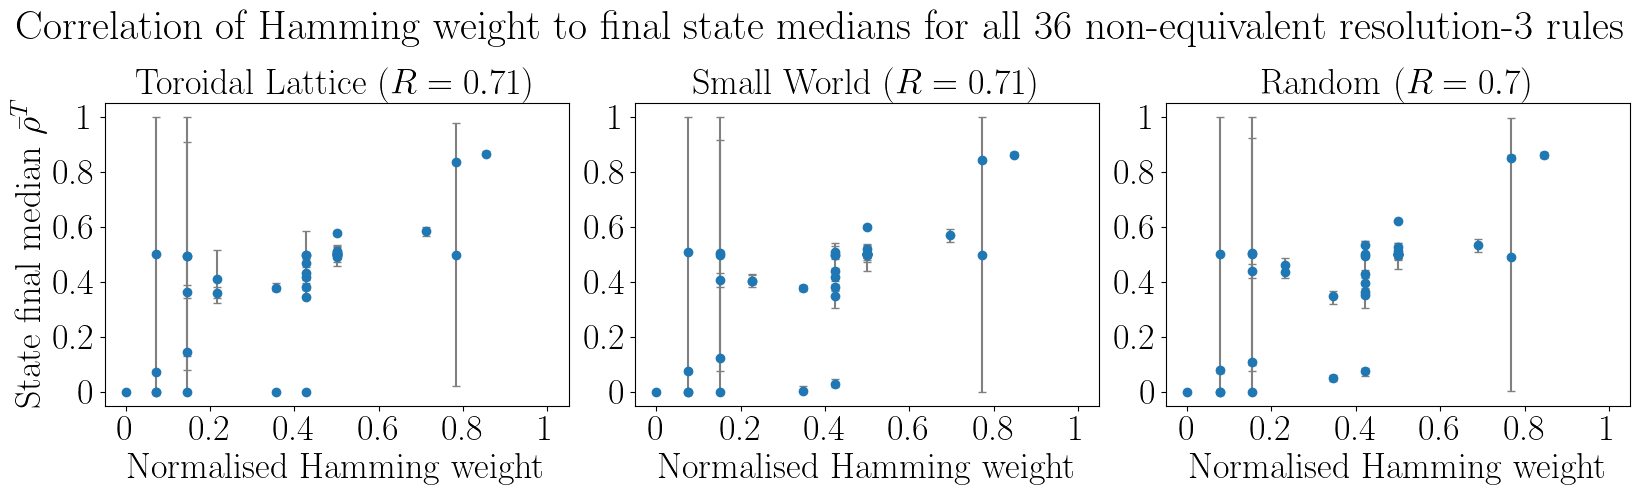

In [30]:
from scipy.stats import pearsonr

fig, axs = plt.subplots(1,3,figsize=(16.5,5))
fontsize=26

for idx, ax in enumerate(axs):
    # get relevant arrays
    graph_name = graph_names[idx]
    state_medians = state_medians_per_type[idx]
    state_err = np.array([state_medians - state_q1_per_type[idx], state_q3_per_type[idx] - state_medians])
    hw_medians = hw_medians_per_type[idx]
    hw_err = np.array([hw_medians - hw_q1_per_type[idx], hw_q3_per_type[idx] - hw_medians])

    # Calculate Pearson correlation
    # try:
    #     corr, r_squared = weighted_correlation_asymmetric(hw_medians, state_medians, hw_err, state_err)
    # except:
    #     print(f"weighted correlation does not work for {graph_name}.")
    corr, _ = pearsonr(hw_medians, state_medians)
    r_squared = corr**2

    # Create scatter plot with uncertainty crosses
    ax.errorbar(hw_medians, state_medians, xerr=hw_err, yerr=state_err, fmt='o', ecolor='gray', capsize=3)
    # make nice labels
    ax.set_xlabel('Normalised Hamming weight', fontsize=fontsize)
    # ax.set_ylabel('State final median $\\bar{\\rho}^T$', fontsize=fontsize)
    ax.set_title(f'{graph_name} ($R = {np.round(corr,2)}$)', fontsize=fontsize)

    # get identical limits for each plot
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    xticks = [0, .2, .4, .6, .8, 1]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=fontsize)
    yticks = [0, .2, .4, .6, .8, 1]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=fontsize)

axs[0].set_ylabel('State final median $\\bar{\\rho}^T$', fontsize=fontsize)

fig.suptitle(f"Correlation of Hamming weight to final state medians for all $36$ non-equivalent resolution-$3$ rules", fontsize=fontsize+4)
fig.tight_layout()

savename = f"state-median-vs-hamming-weight_resolution3.pdf"
# plt.savefig(savename, bbox_inches='tight')

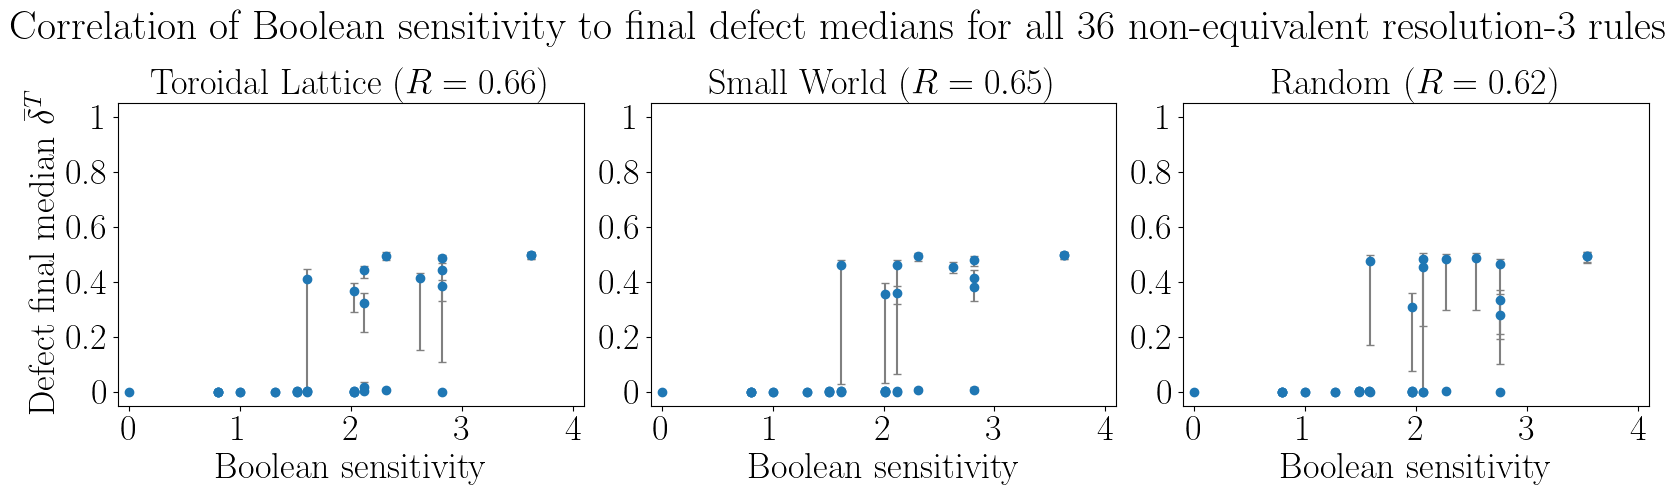

In [ ]:
from scipy.stats import pearsonr

fig, axs = plt.subplots(1,3,figsize=(16.5,5))
fontsize=26

for idx, ax in enumerate(axs):
    # get relevant arrays
    graph_name = graph_names[idx]
    defect_medians = defect_medians_per_type[idx]
    defect_err = np.array([defect_medians - defect_q1_per_type[idx], defect_q3_per_type[idx] - defect_medians])
    bs_medians = bs_medians_per_type[idx]
    bs_err = np.array([bs_medians - bs_q1_per_type[idx], bs_q3_per_type[idx] - bs_medians])

    # Calculate Pearson correlation
    # try:
    #     corr, r_squared = weighted_correlation_asymmetric(bs_medians, defect_medians, bs_err, defect_err)
    # except:
    #     print(f"weighted correlation does not work for {graph_name}.")
    corr, _ = pearsonr(bs_medians, defect_medians)
    r_squared = corr**2

    # Create scatter plot with uncertainty crosses
    ax.errorbar(bs_medians, defect_medians, xerr=bs_err, yerr=defect_err, fmt='o', ecolor='gray', capsize=3)

    # make nice labels
    ax.set_xlabel('Boolean sensitivity', fontsize=fontsize)
    # ax.set_ylabel('Defect final median $\\bar{\\delta}^T$', fontsize=fontsize)
    ax.set_title(f'{graph_name} ($R = {np.round(corr,2)}$)', fontsize=fontsize)

    # get identical limits for each plot
    ax.set_xlim([-0.1, 4.1])
    ax.set_ylim([-0.05, 1.05])
    xticks = [0, 1, 2, 3, 4]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, fontsize=fontsize)
    yticks = [0, .2, .4, .6, .8, 1]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=fontsize)

axs[0].set_ylabel('Defect final median $\\bar{\\delta}^T$', fontsize=fontsize)

fig.suptitle(f"Correlation of Boolean sensitivity to final defect medians for all $36$ non-equivalent resolution-$3$ rules", fontsize=fontsize+4)
fig.tight_layout()

savename = f"defect-median-vs-boolean-sens_resolution3.pdf"
# plt.savefig(savename, bbox_inches='tight')